In [1]:
import copy

import numpy as np
import matplotlib.pyplot as plt

import srwave

insert:
- how to use coords=x-y and part=re-im
- count points func
- calculo de radiacao com trajetoria, sem inserir campo
- calculo de radiacao para apenas um e, x, y ou so' y como array
- calculo e plot de trajetoria com fields
- tentar plot em que se ve limites horizontais da radiacao de bending

# Spectrum

## Bending

flux density

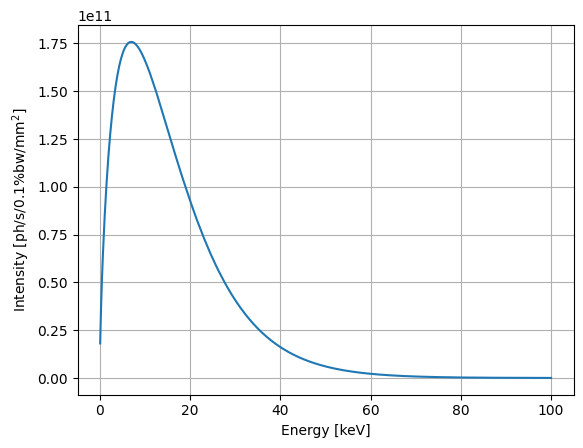

In [2]:
energy = np.linspace(0.1, 100, 500) * 1e3

bm = srwave.BendingMagnet(B=1.4, L=3)
fields = srwave.MagnetCnt(magnets=bm, fieldtype='bending')

SR = srwave.SynchrotronRadiation(energy=energy, d=10, x=0, y=0, fields=fields)
SR.calc_wfr()

arrI, [rangee] = SR.calc_intensity(coords='e', energy=0, X=0, Y=0, polarization='total', calctype='SE')

plt.plot(energy*1e-3,arrI)
plt.xlabel('Energy [keV]')
plt.ylabel(r'Intensity [ph/s/0.1%bw/mm$^2$]')
plt.grid()
plt.show()

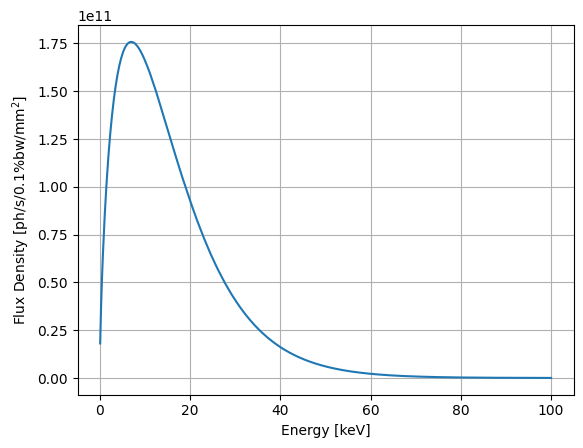

In [3]:
energy = np.linspace(0.1, 100, 500) * 1e3

bm = srwave.BendingMagnet(B=1.4, L=3)
fields = srwave.MagnetCnt(magnets=bm, fieldtype='bending')

SR = srwave.SynchrotronRadiation(energy=energy, d=10, x=0, y=0, fields=fields)
SR.calc_wfr()

SR.plot_spectrum()

## Undulator

flux density

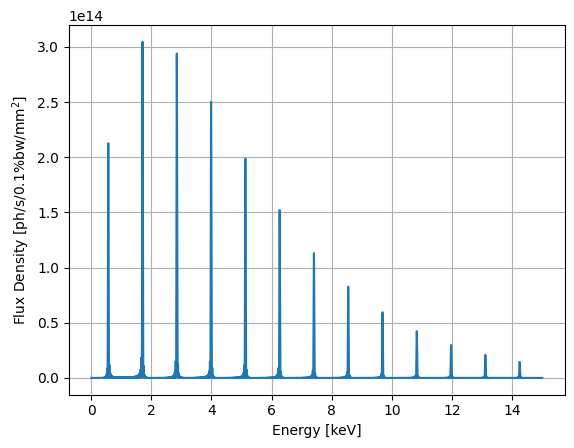

In [5]:
und = srwave.Undulator(period_length=50e-3, nr_periods=20, Ky=2, Kx=0)
fields = srwave.MagnetCnt(magnets=und, fieldtype='undulator')

energy = np.linspace(0.01, 15, 7000) * 1e3
# adjust the array for the energy points pass exactly on the harmonics into the range:
energy = und.adjust_energy(energy=energy, E=3e9, theta=0)

SR = srwave.SynchrotronRadiation(energy=energy, d=10, x=0, y=0, fields=fields)
SR.calc_wfr()

SR.plot_spectrum()

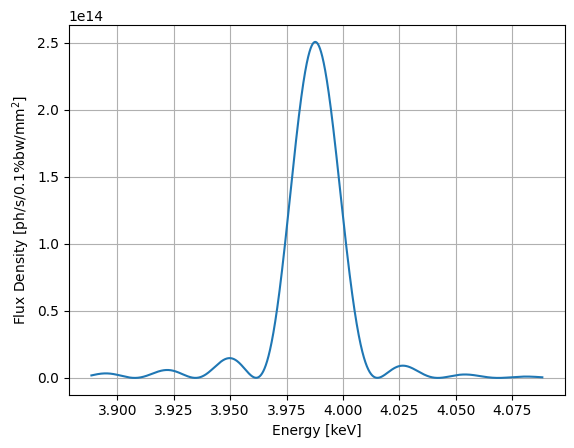

In [6]:
und = srwave.Undulator(period_length=50e-3, nr_periods=20, Ky=2, Kx=0)
fields = srwave.MagnetCnt(magnets=und, fieldtype='undulator')

energy_7 = und.harmonic_energy(harmn=7, E=3e9, theta=0)
# odd len to ensure, without the adjust func, the presence of energy 7
energy = np.linspace(energy_7-100, energy_7+100, 7001)

SR = srwave.SynchrotronRadiation(energy=energy, d=10, x=0, y=0, fields=fields)
SR.calc_wfr()

SR.plot_spectrum()

flux

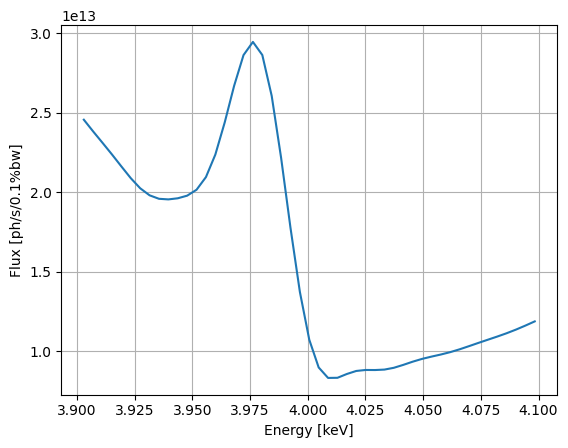

In [7]:
und = srwave.Undulator(period_length=50e-3, nr_periods=20, Ky=2, Kx=0)
fields = srwave.MagnetCnt(magnets=und, fieldtype='undulator')

w = np.linspace(-5e-4, 5e-4, 200)
energy = np.linspace(4-0.1,4+0.1,50)*1e3
# adjust the array for the energy points pass exactly on the harmonics into the range:
energy = und.adjust_energy(energy=energy, E=3e9, theta=0)

SR = srwave.SynchrotronRadiation(energy=energy, d=5, x=w, y=w, fields=fields)
SR.calc_wfr()

arrF, [rangee] = SR.calc_flux(polarization='total', calctype='SE')

plt.plot(energy*1e-3, arrF)
plt.xlabel('Energy [keV]')
plt.ylabel(r'Flux [ph/s/0.1%bw]')
plt.grid()
plt.show()

In [7]:
energy

array([3902.99629927, 3907.06615986, 3911.13602044, 3915.20588102,
       3919.27574161, 3923.34560219, 3927.41546277, 3931.48532336,
       3935.55518394, 3939.62504452, 3943.69490511, 3947.76476569,
       3951.83462627, 3955.90448686, 3959.97434744, 3964.04420802,
       3968.1140686 , 3972.18392919, 3976.25378977, 3980.32365035,
       3984.39351094, 3988.46337152, 3992.5332321 , 3996.60309269,
       4000.67295327, 4004.74281385, 4008.81267444, 4012.88253502,
       4016.9523956 , 4021.02225619, 4025.09211677, 4029.16197735,
       4033.23183794, 4037.30169852, 4041.3715591 , 4045.44141969,
       4049.51128027, 4053.58114085, 4057.65100143, 4061.72086202,
       4065.7907226 , 4069.86058318, 4073.93044377, 4078.00030435,
       4082.07016493, 4086.14002552, 4090.2098861 , 4094.27974668,
       4098.34960727])

In [8]:
arrF

array([2.4561165e+13, 2.3818253e+13, 2.3100224e+13, 2.2372459e+13,
       2.1620381e+13, 2.0883203e+13, 2.0248701e+13, 1.9805694e+13,
       1.9586634e+13, 1.9548491e+13, 1.9618580e+13, 1.9783339e+13,
       2.0155447e+13, 2.0952430e+13, 2.2368418e+13, 2.4394372e+13,
       2.6693262e+13, 2.8626544e+13, 2.9454116e+13, 2.8631089e+13,
       2.6059930e+13, 2.2167463e+13, 1.7760753e+13, 1.3727357e+13,
       1.0721592e+13, 8.9779004e+12, 8.3191765e+12, 8.3267315e+12,
       8.5663972e+12, 8.7570750e+12, 8.8193588e+12, 8.8154277e+12,
       8.8434425e+12, 8.9559107e+12, 9.1382497e+12, 9.3389524e+12,
       9.5150733e+12, 9.6584849e+12, 9.7909463e+12, 9.9400821e+12,
       1.0118061e+13, 1.0317195e+13, 1.0521297e+13, 1.0720688e+13,
       1.0918916e+13, 1.1127955e+13, 1.1357793e+13, 1.1609260e+13,
       1.1874812e+13], dtype=float32)

In [ ]:
und = srwave.Undulator(period_length=50e-3, nr_periods=20, Kv=2, Kh=0)
fields = srwave.MagnetCnt(magnets=und, fieldtype='undulator')

energy = [3902.99629927,]
w = np.linspace(-5e-4, 5e-4, 200)

SR = srwave.SynchrotronRadiation(energy=Eph, d=5, x=w, y=w, fields=fields)
SR.calc_wfr()

arrF, [rangee] = SR.calc_flux(polarization='total', calctype='SE')

arrF

array([2.9356785e+13], dtype=float32)

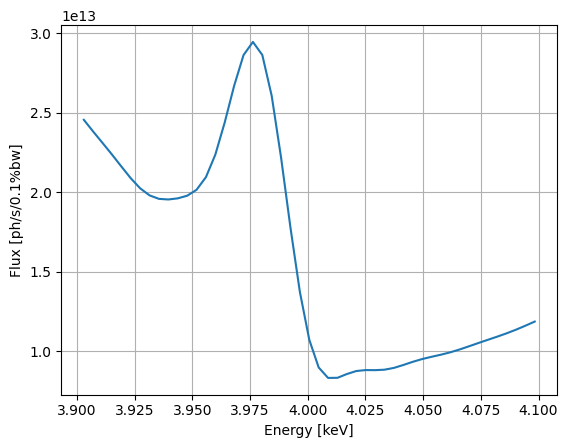

In [9]:
und = srwave.Undulator(period_length=50e-3, nr_periods=20, Ky=2, Kx=0)
fields = srwave.MagnetCnt(magnets=und, fieldtype='undulator')

w = np.linspace(-5e-4, 5e-4, 100)
energy = np.linspace(4-0.1, 4+0.1, 50) * 1e3
# adjust the array for the energy points pass exactly on the harmonics into the range:
energy = und.adjust_energy(energy=energy, E=3e9, theta=0)

SR = srwave.SynchrotronRadiation(energy=energy, d=5, x=w, y=w, fields=fields)
SR.calc_wfr()

SR.plot_flux()

# Spatial distributions

## Bending

flux densities: horizontal and transverse plane profiles

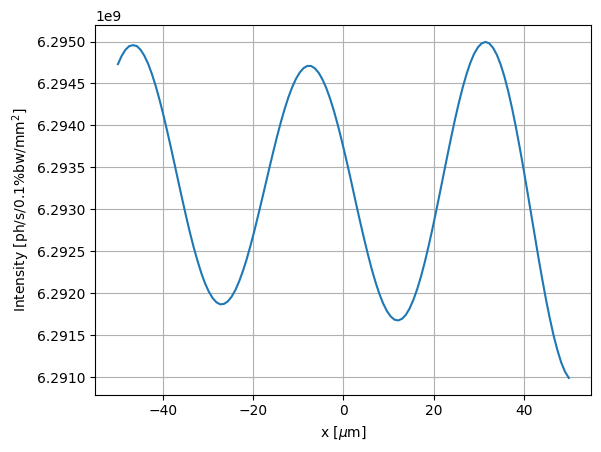

In [10]:
Eph = 20e3
w = np.linspace(-50, 50, 120) * 1e-6

bm = srwave.BendingMagnet(B=0.5642, L=3)
fields = srwave.MagnetCnt(magnets=bm, fieldtype='bending')

SR = srwave.SynchrotronRadiation(energy=Eph, d=10, x=w, y=w, fields=fields)
SR.calc_wfr()

arrI, [rangex] = SR.calc_intensity(coords='x', energy=Eph, X=0, Y=0, polarization='total', calctype='SE')
x = np.linspace(*rangex) * 1e6

plt.plot(x, arrI)
plt.xlabel(r'x [$\mu$m]')
plt.ylabel(r'Intensity [ph/s/0.1%bw/mm$^2$]')
plt.grid()
plt.show()

# OBS: Notice the scale of variation of the intensity. The oscillation is result of accumulation of numerical errors, the intensity is almost constant or constant varying

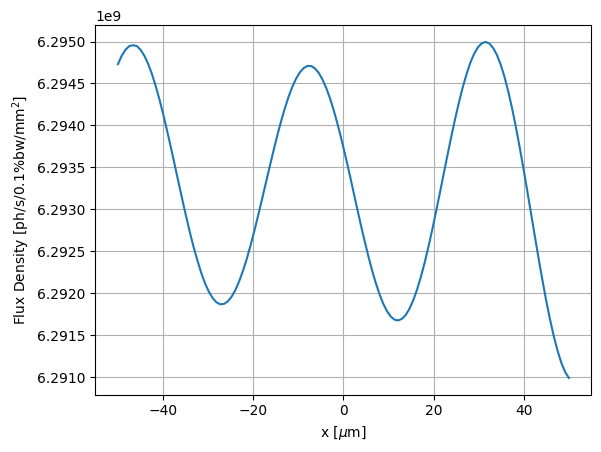

In [12]:
Eph = 20e3
w = np.linspace(-50,50,120)*1e-6

bm = srwave.BendingMagnet(B=0.5642,L=3)
fields = srwave.MagnetCnt(magnets=[bm],fieldtype='bending')

SR = srwave.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()

SR.plot_intensity(coords='x',energy=Eph,Y=0)

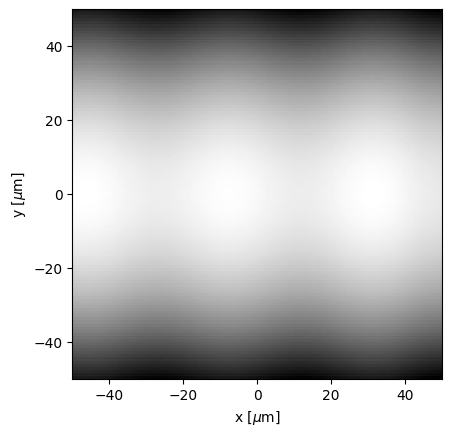

In [13]:
Eph = 20e3
w = np.linspace(-50,50,120)*1e-6

bm = srwave.BendingMagnet(B=0.5642,L=3)
fields = srwave.MagnetCnt(magnets=[bm],fieldtype='bending')

SR = srwave.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()

SR.plot_intensity(coords='xy',energy=Eph,calctype='SE')

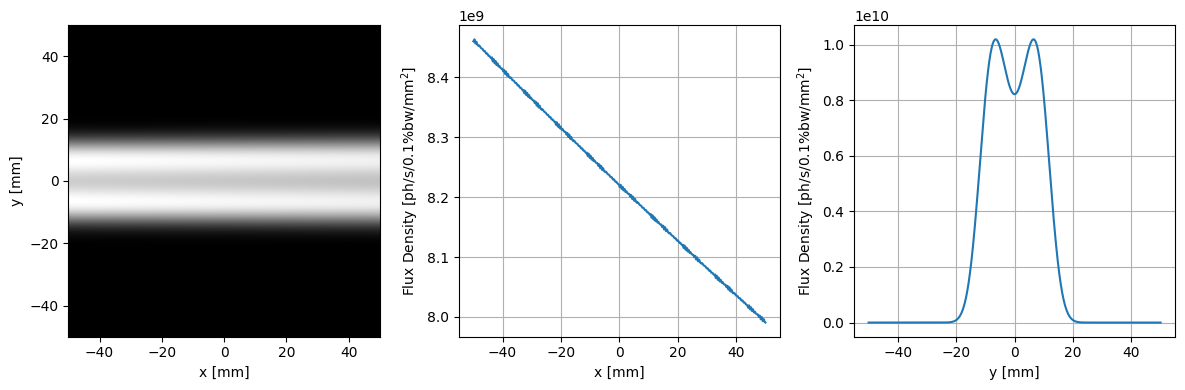

In [14]:
bm = srwave.BendingMagnet(B=1.4,L=4)
fields = srwave.MagnetCnt(magnets=[bm],fieldtype='bending')

Eph = srwave.utils.wavelength_to_energy(325e-9)
w = np.linspace(-50,50,100)*1e-3

SR = srwave.SynchrotronRadiation(energy=Eph,d=5,x=w,y=w,fields=fields)
SR.precisions['sampling'] = 0.1
SR.calc_wfr()


plt.figure(figsize=(12,4))
ax1 = plt.subplot(1,3,1)
ax2 = plt.subplot(1,3,2)
ax3 = plt.subplot(1,3,3)

SR.plot_intensity(coords='xy',energy=Eph, ax=ax1, aspect='equal',
                  xunitprefix='m',yunitprefix='m')
SR.plot_intensity(coords='x',energy=Eph,Y=0, ax=ax2,
                  xunitprefix='m')
SR.plot_intensity(coords='y',energy=Eph,X=0, ax=ax3,
                  xunitprefix='m')

plt.tight_layout()
plt.show()

polarizations

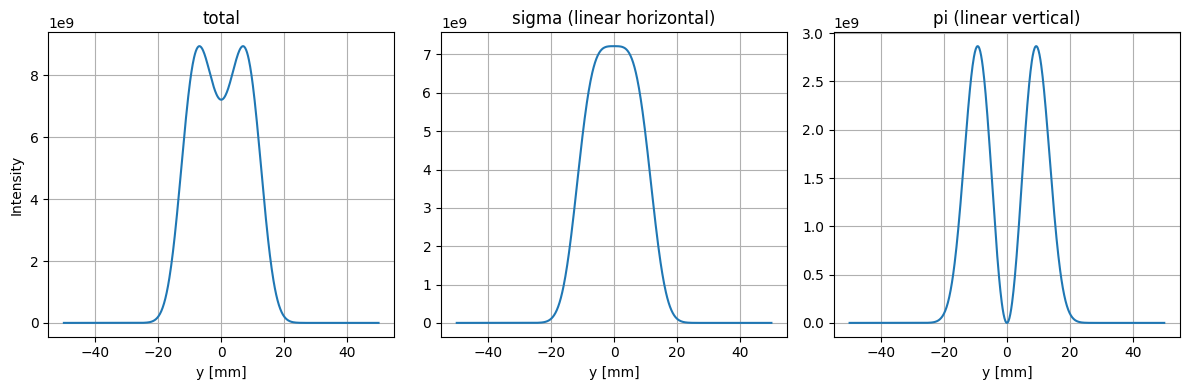

In [16]:
bm = srwave.BendingMagnet(B=1.4,L=4)
fields = srwave.MagnetCnt(magnets=[bm],fieldtype='bending')

Eph = srwave.utils.wavelength_to_energy(325e-9)
w = np.linspace(-50,50,100)*1e-3

SR = srwave.SynchrotronRadiation(energy=Eph,d=5.336,x=w,y=w,fields=fields)
SR.precisions['sampling'] = 0.1
SR.calc_wfr()


plt.figure(figsize=(12,4))
ax1 = plt.subplot(1,3,1)
ax2 = plt.subplot(1,3,2)
ax3 = plt.subplot(1,3,3)

SR.plot_intensity(coords='y',energy=Eph,X=0,polarization='total',ax=ax1,
                  title='total',ylabel='Intensity',xunitprefix='m')
SR.plot_intensity(coords='y',energy=Eph,X=0,polarization='linH',ax=ax2,
                  title='sigma (linear horizontal)',ylabel='',xunitprefix='m')
SR.plot_intensity(coords='y',energy=Eph,X=0,polarization='linV',ax=ax3,
                  title='pi (linear vertical)',ylabel='',xunitprefix='m')

plt.tight_layout()
plt.show()

phase

In [29]:
Eph = 20e3
w = np.linspace(-50,50,120)*1e-6

bm = srwave.BendingMagnet(B=0.5642,L=3)
fields = srwave.MagnetCnt(magnets=[bm],fieldtype='bending')

SR = srwave.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()

arrP, [rangex, rangey] = SR.calc_electric_field(part='phase',coords='xy',energy=0,X=0,Y=0)
xi, xf, nx, yi, yf, ny = *rangex, *rangey
arrP = np.array(arrP).reshape(ny,nx)

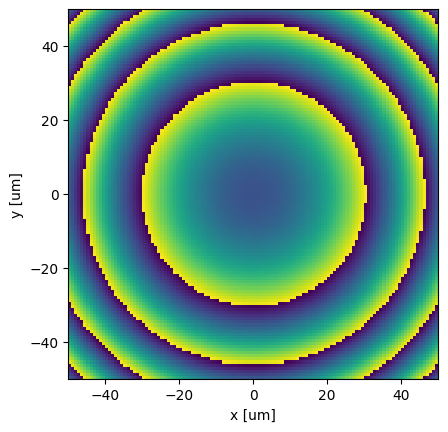

In [31]:
limits = SR.window_limits(unitprefix='u')

plt.imshow(arrP,extent=limits,aspect='equal')
plt.xlabel('x [um]')
plt.ylabel('y [um]')
plt.show()

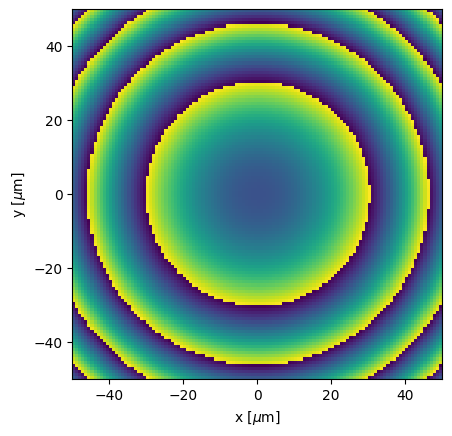

In [30]:
SR.plot_electric_field(part='phase',coords='xy',cmap='viridis')

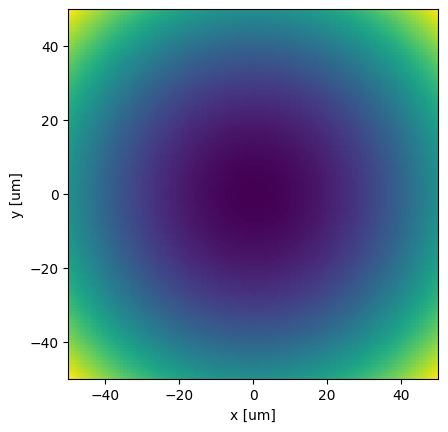

In [32]:
arrP_unw = srwave.SynchrotronRadiation.unwrap_phase(arrP)

plt.imshow(arrP_unw,extent=limits,aspect='equal')
plt.xlabel('x [um]')
plt.ylabel('y [um]')
plt.show()

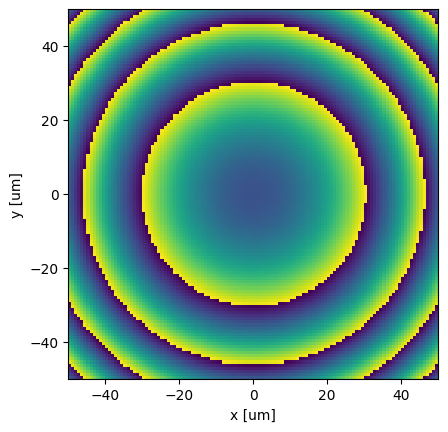

In [34]:
arrP_w = srwave.SynchrotronRadiation.wrap_phase(arrP_unw)

plt.imshow(arrP_w,extent=limits,aspect='equal')
plt.xlabel('x [um]')
plt.ylabel('y [um]')
plt.show()

## Undulator

flux density

In [35]:
und = srwave.Undulator(period_length=50e-3,nr_periods=20,Ky=2,Kx=0)
fields = srwave.MagnetCnt(magnets=[und],fieldtype='undulator')

w = np.linspace(-5e-4,5e-4,200)
Eph = und.harmonic_energy(harmn=1,E=3e9,theta=0)

SR = srwave.SynchrotronRadiation(energy=Eph,d=5,x=w,y=w,fields=fields)
SR.calc_wfr()

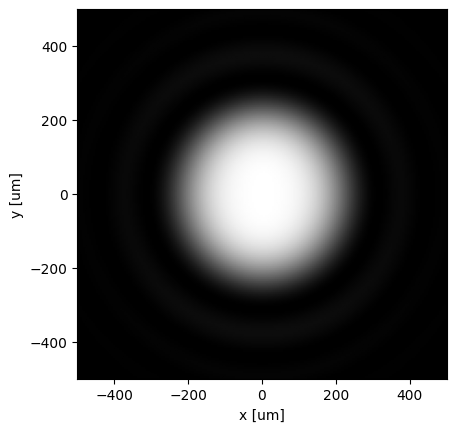

In [36]:
arrI, [rangex,rangey] = SR.calc_intensity(coords='xy',energy=SR.wfr.mesh.eStart,X=0,Y=0,polarization='total',calctype='SE')
xi, xf, nx, yi, yf, ny = *rangex, *rangey
arrI = np.array(arrI).reshape(ny,nx)

limits = SR.window_limits(unitprefix='u')
plt.imshow(arrI,cmap='gray',extent=limits)
plt.ylabel('y [um]')
plt.xlabel('x [um]')
plt.show()

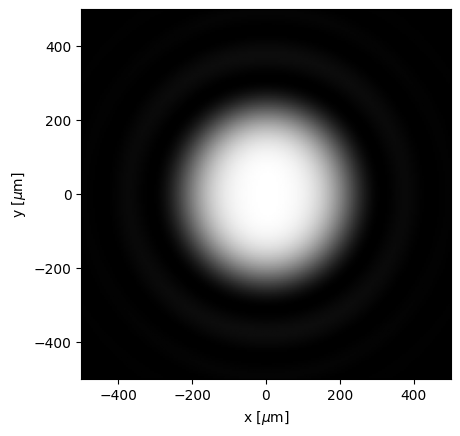

In [37]:
SR.plot_intensity(coords='xy',energy=Eph)

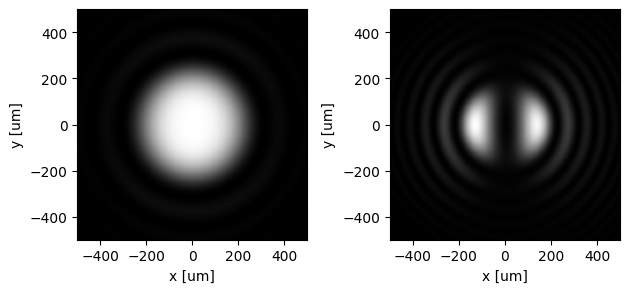

In [40]:
und = srwave.Undulator(period_length=50e-3,nr_periods=20,Ky=2,Kx=0)
fields = srwave.MagnetCnt(magnets=[und],fieldtype='undulator')

w = np.linspace(-5e-4,5e-4,200)
Eph1 = und.harmonic_energy(harmn=1,E=3e9,theta=0)
Eph2 = und.harmonic_energy(harmn=2,E=3e9,theta=0)

ax1 = plt.subplot(121)
ax2 = plt.subplot(122)

for ax, Eph in zip([ax1,ax2],[Eph1,Eph2]):

    SR = srwave.SynchrotronRadiation(energy=Eph,d=5,x=w,y=w,fields=fields)
    SR.calc_wfr()

    arrI, [rangex,rangey] = SR.calc_intensity(coords='xy',energy=SR.wfr.mesh.eStart,X=0,Y=0,polarization='total',calctype='SE')
    xi, xf, nx, yi, yf, ny = *rangex, *rangey
    arrI = np.array(arrI).reshape(ny,nx)

    limits = SR.window_limits()
    ax.imshow(arrI,cmap='gray',extent=limits)
    ax.set_ylabel('y [um]')
    ax.set_xlabel('x [um]')

plt.tight_layout()
plt.show()

## Gaussian

mode TEM00 and TEM21: transverse profiles of flux density

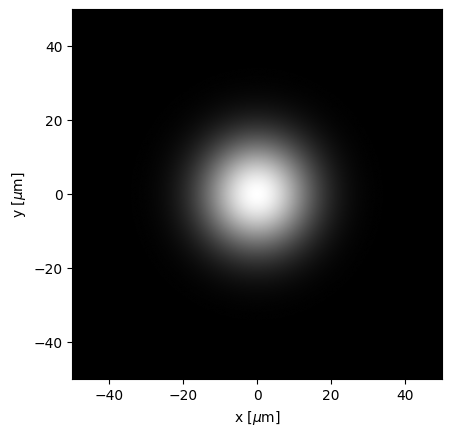

In [41]:
# TEM00 #

Eph = 8e3
w = np.linspace(-50,50,1000) * 1e-6

GR = srwave.GaussianRadiation(energy=Eph,x=w,y=w,d=2)
GR.gaussianbeam.set_mode(modex=0,modey=0)
GR.calc_wfr()

GR.plot_intensity(coords='xy',energy=Eph)

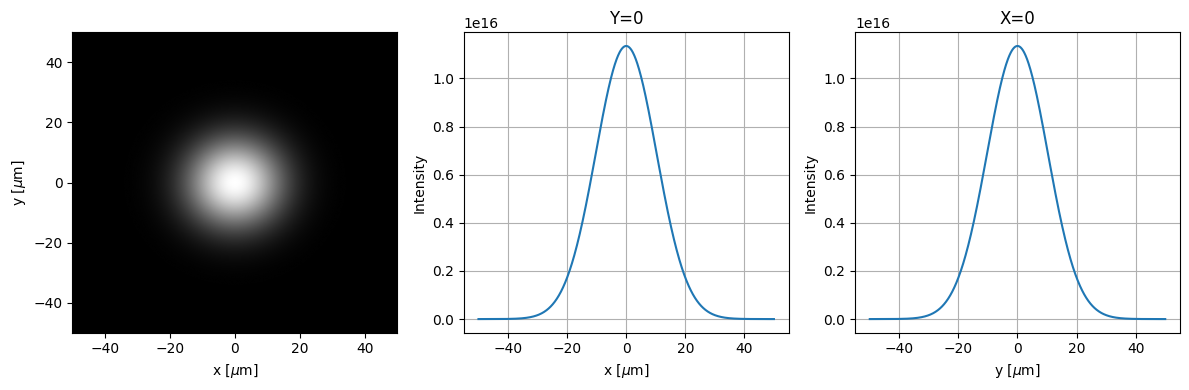

In [43]:
plt.figure(figsize=(12,4))

ax_xy = plt.subplot(1,3,1)
ax_x = plt.subplot(1,3,2)
ax_y = plt.subplot(1,3,3)

GR.plot_intensity(coords='xy', energy=Eph, X=0, Y=0, ax=ax_xy, aspect='auto',
                  xlabel=r'x [$\mu$m]', ylabel=r'y [$\mu$m]')
GR.plot_intensity(coords='x', energy=Eph, X=0, Y=0, ax=ax_x,
                  title='Y=0', xlabel=r'x [$\mu$m]', ylabel='Intensity')
GR.plot_intensity(coords='y', energy=Eph, X=0, Y=0, ax=ax_y,
                  title='X=0', xlabel=r'y [$\mu$m]', ylabel='Intensity')

plt.tight_layout()
plt.show()

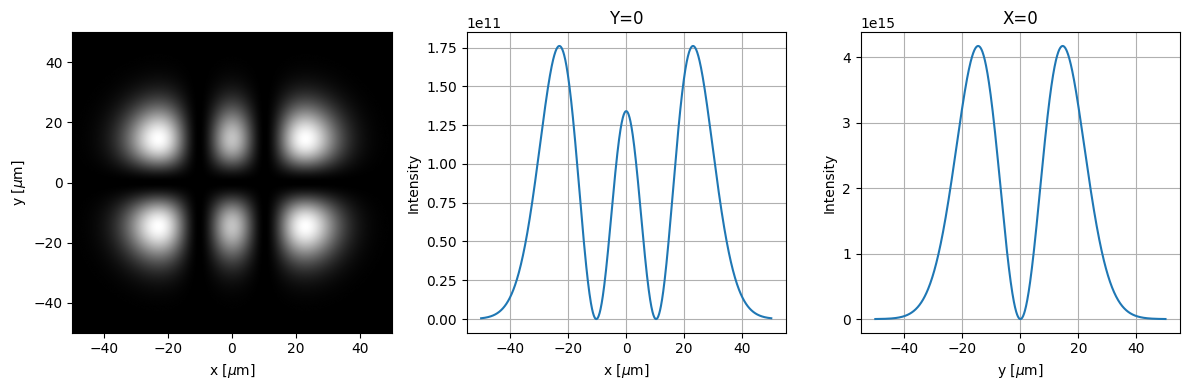

In [44]:
# TEM21 #

Eph = 8e3
w = np.linspace(-50,50,1000) * 1e-6

GR = srwave.GaussianRadiation(energy=Eph,x=w,y=w,d=2)
GR.gaussianbeam.set_mode(modex=2,modey=1)
GR.calc_wfr()

plt.figure(figsize=(12,4))

ax_xy = plt.subplot(1,3,1)
ax_x = plt.subplot(1,3,2)
ax_y = plt.subplot(1,3,3)

GR.plot_intensity(coords='xy', energy=Eph, X=0, Y=0, ax=ax_xy, aspect='auto',
                  xlabel=r'x [$\mu$m]', ylabel=r'y [$\mu$m]')
GR.plot_intensity(coords='x', energy=Eph, X=0, Y=0, ax=ax_x,
                  title='Y=0', xlabel=r'x [$\mu$m]', ylabel='Intensity')
GR.plot_intensity(coords='y', energy=Eph, X=0, Y=0, ax=ax_y,
                  title='X=0', xlabel=r'y [$\mu$m]', ylabel='Intensity')

plt.tight_layout()
plt.show()

mode TEM00 and TEM21: caustic

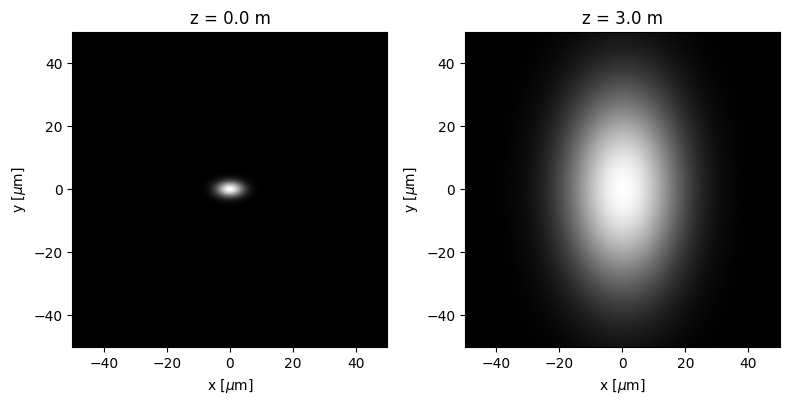

In [45]:
# TEM00 #

Eph = 8e3
w = np.linspace(-50,50,1000) * 1e-6
dist0 = 0
fwhmx, fwhmy = 7e-6, 4e-6
rmst = 10e-15

GR = srwave.GaussianRadiation(energy=Eph,x=w,y=w,d=dist0)
GR.gaussianbeam.set_waist(sigX=fwhmx/2.355, sigY=fwhmy/2.355, sigT=rmst)
GR.gaussianbeam.set_mode(modex=0,modey=0)


plt.figure(figsize=(8,4))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

GR.wfr.mesh.zStart = 3
GR.calc_wfr()

GR.plot_intensity(coords='xy', energy=Eph, ax=ax2,
                  title=f'z = {GR.wfr.mesh.zStart} m',
                  xlabel=r'x [$\mu$m]')

GR.wfr.mesh.zStart = dist0
GR.calc_wfr()

GR.plot_intensity(coords='xy', energy=Eph, ax=ax1,
                  title=f'z = {GR.wfr.mesh.zStart} m',
                  xlabel=r'x [$\mu$m]', ylabel=r'y [$\mu$m]')

plt.tight_layout()
plt.show()

In [47]:
dists = np.linspace(-3,3,200)

arrsIx = []
arrsIy = []

for dist in dists:
    GRcopy = copy.deepcopy(GR)

    space = srwave.Drift(distance=dist)
    bl = srwave.Beamline(radiation=GRcopy, opt_elements=space)
    bl.propagate_wfr()

    (arrIx, [rangex]), (arrIy, [rangey]) = GRcopy.calc_intensity(
        coords='x-y',energy=Eph,X=0,Y=0
    )

    arrsIx.append(arrIx)
    arrsIy.append(arrIy)

arrsIx = np.array(arrsIx).T
arrsIy = np.array(arrsIy).T

maxsx = np.max(arrsIx, axis=0)
maxsy = np.max(arrsIy, axis=0)

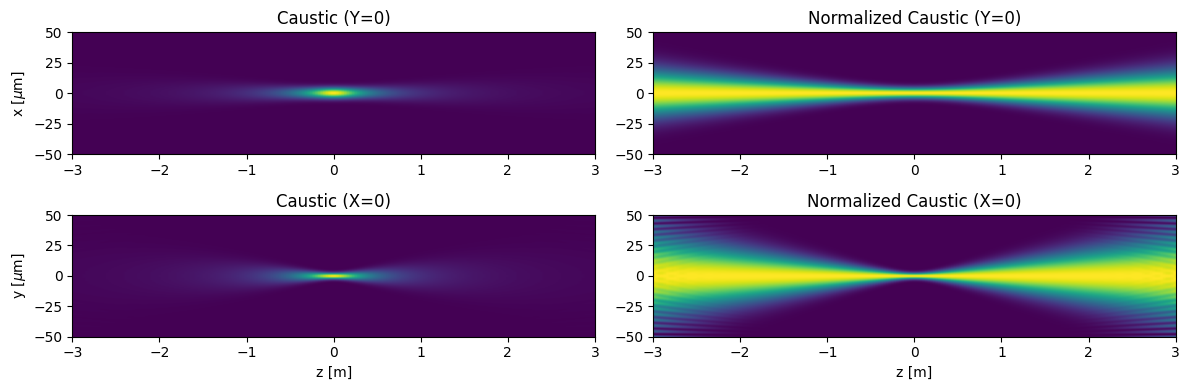

In [48]:
plt.figure(figsize=(12,4))
ax1 = plt.subplot(2,2,1)
ax2 = plt.subplot(2,2,2)
ax3 = plt.subplot(2,2,3)
ax4 = plt.subplot(2,2,4)

limitsx = [dist0+dists[0], dist0+dists[-1], rangex[0]*1e6, rangex[1]*1e6]
limitsy = [dist0+dists[0], dist0+dists[-1], rangey[0]*1e6, rangey[1]*1e6]

ax1.imshow(arrsIx, extent=limitsx, aspect='auto', cmap='viridis')
ax1.set(title='Caustic (Y=0)', ylabel=r'x [$\mu$m]')

ax2.imshow(arrsIx/maxsx, extent=limitsx, aspect='auto', cmap='viridis')
ax2.set(title='Normalized Caustic (Y=0)')

ax3.imshow(arrsIy, extent=limitsy, aspect='auto', cmap='viridis')
ax3.set(title='Caustic (X=0)', xlabel='z [m]', ylabel=r'y [$\mu$m]')

ax4.imshow(arrsIy/maxsy, extent=limitsy, aspect='auto', cmap='viridis')
ax4.set(title='Normalized Caustic (X=0)', xlabel='z [m]')

plt.tight_layout()
plt.show()

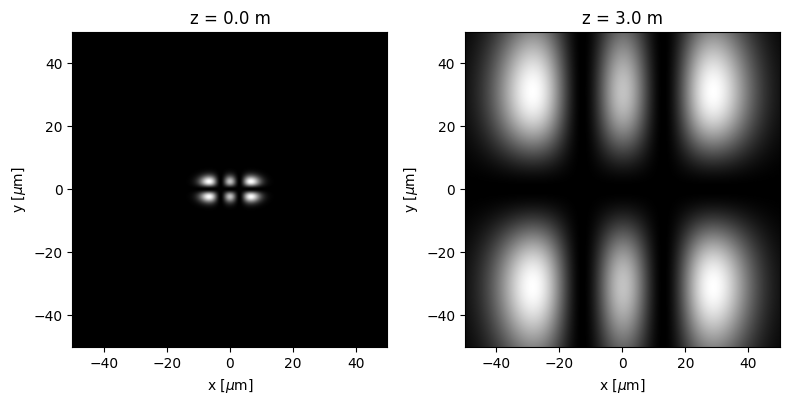

In [49]:
# TEM21 #

Eph = 8e3
w = np.linspace(-50,50,1000) * 1e-6
dist0 = 0
fwhmx, fwhmy = 7e-6, 4e-6
rmst = 10e-15

GR = srwave.GaussianRadiation(energy=Eph,x=w,y=w,d=dist0)
GR.gaussianbeam.set_waist(sigX=fwhmx/2.355, sigY=fwhmy/2.355, sigT=rmst)
GR.gaussianbeam.set_mode(modex=2,modey=1)


plt.figure(figsize=(8,4))
ax1 = plt.subplot(1,2,1)
ax2 = plt.subplot(1,2,2)

GR.wfr.mesh.zStart = 3
GR.calc_wfr()

GR.plot_intensity(coords='xy', energy=Eph, ax=ax2,
                  title=f'z = {GR.wfr.mesh.zStart} m',
                  xlabel=r'x [$\mu$m]')

GR.wfr.mesh.zStart = dist0
GR.calc_wfr()

GR.plot_intensity(coords='xy', energy=Eph, ax=ax1,
                  title=f'z = {GR.wfr.mesh.zStart} m',
                  xlabel=r'x [$\mu$m]', ylabel=r'y [$\mu$m]')

plt.tight_layout()
plt.show()

In [50]:
dists = np.linspace(-3,3,200)

arrsIx = []
arrsIy = []

for dist in dists:
    GRcopy = copy.deepcopy(GR)

    space = srwave.Drift(distance=dist)
    bl = srwave.Beamline(radiation=GRcopy, opt_elements=space)
    bl.propagate_wfr()

    (arrIx, [rangex]), (arrIy, [rangey]) = GRcopy.calc_intensity(
        coords='x-y',energy=Eph,X=0,Y=0
    )

    arrsIx.append(arrIx)
    arrsIy.append(arrIy)

arrsIx = np.array(arrsIx).T
arrsIy = np.array(arrsIy).T

maxsx = np.max(arrsIx, axis=0)
maxsy = np.max(arrsIy, axis=0)

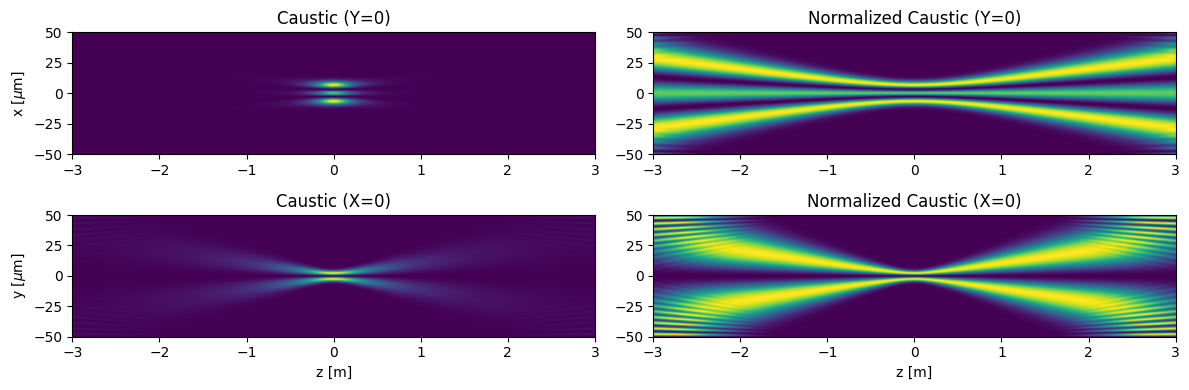

In [51]:
plt.figure(figsize=(12,4))
ax1 = plt.subplot(2,2,1)
ax2 = plt.subplot(2,2,2)
ax3 = plt.subplot(2,2,3)
ax4 = plt.subplot(2,2,4)

limitsx = [dist0+dists[0], dist0+dists[-1], rangex[0]*1e6, rangex[1]*1e6]
limitsy = [dist0+dists[0], dist0+dists[-1], rangey[0]*1e6, rangey[1]*1e6]

ax1.imshow(arrsIx, extent=limitsx, aspect='auto', cmap='viridis')
ax1.set(title='Caustic (Y=0)', ylabel=r'x [$\mu$m]')

ax2.imshow(arrsIx/maxsx, extent=limitsx, aspect='auto', cmap='viridis')
ax2.set(title='Normalized Caustic (Y=0)')

ax3.imshow(arrsIy, extent=limitsy, aspect='auto', cmap='viridis')
ax3.set(title='Caustic (X=0)', xlabel='z [m]', ylabel=r'y [$\mu$m]')

ax4.imshow(arrsIy/maxsy, extent=limitsy, aspect='auto', cmap='viridis')
ax4.set(title='Normalized Caustic (X=0)', xlabel='z [m]')

plt.tight_layout()
plt.show()

## Point Source

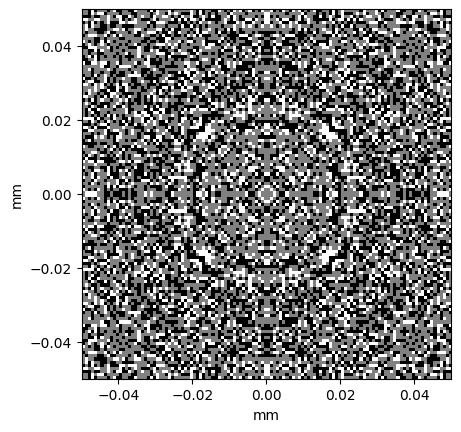

In [58]:
Eph = 20e3
w = np.linspace(-50,50,120) * 1e-6

PR = srwave.PointRadiation(energy=Eph,x=w,y=w,d=10)
PR.calc_wfr()

PR.plot_intensity(coords='xy',energy=Eph,unit='mm',xlabel='mm',ylabel='mm')

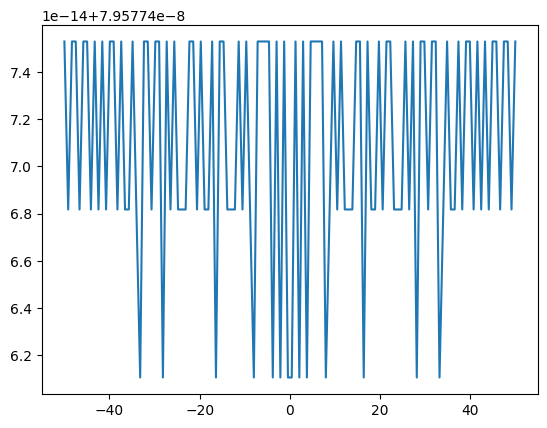

In [52]:
PR.plot_intensity(coords='x')

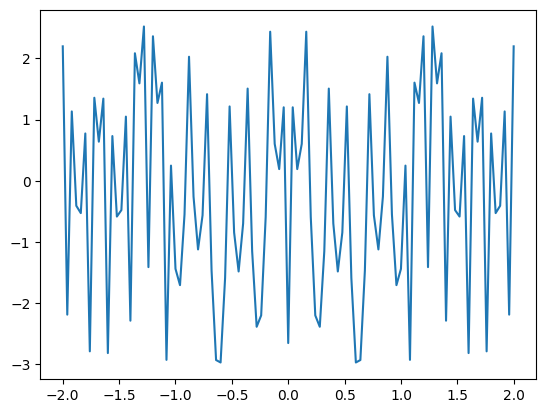

In [40]:
PR.plot_electric_field(part='phase',coords='x',unit='mm')

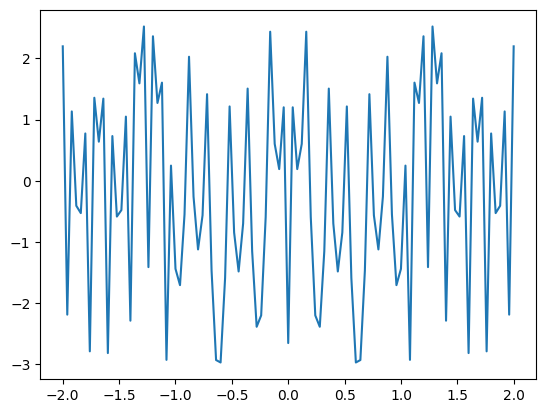

In [38]:
PR.plot_electric_field(part='phase',coords='x',unit='mm')

# Optical elements

drift

In [52]:
drift = srwave.optics.Drift(distance=10)

propagation parameters

In [53]:
drift = srwave.optics.Drift(distance=10)
drift.prop_params['propagator'] = 'Quadratic'
drift.prop_params['ra'] = 4 # horizontal and vertical range factors
drift.prop_params['re'] = 2 # horizontal and vertical resolution factors
drift.prop_params['re_v'] = 3 # vertical resolution factor
drift.prop_params['auto_rs_before'] = True # resize wavefront before propagation
# ...

# check the current parameters of some optical element
print(drift.prop_params)

auto_rs_before : True
auto_rs_after  : False
auto_rs_prec   : 1.0
propagator     : 1
rs             : False
ra_h           : 4
re_h           : 2
ra_v           : 4
re_v           : 3
p1             : 0
p2             : 0
p3             : 0



aperture

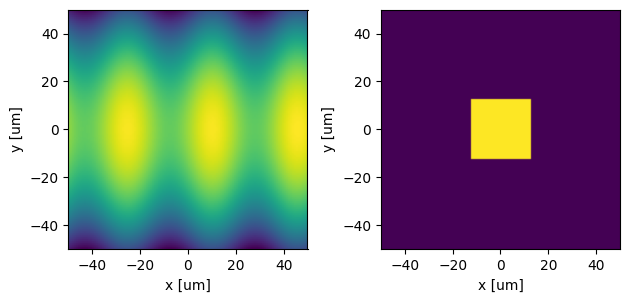

In [55]:
Eph = 22e3

w = np.linspace(-50,50,120)*1e-6

bm = srwave.BendingMagnet(B=0.5642,L=3)
fields = srwave.MagnetCnt(magnets=[bm],fieldtype='bending')

SR = srwave.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()

ax1 = plt.subplot(121)
SR.plot_intensity(coords='xy',energy=Eph,X=0,Y=0,
                  ax=ax1, cmap='viridis', xlabel='x [um]', ylabel='y [um]')


apert = 25e-6

aper = srwave.Slit(apert,apert)

bl = srwave.Beamline(radiation=SR,opt_elements=[aper])
bl.propagate_wfr()

ax2 = plt.subplot(122)
SR.plot_intensity(coords='xy',energy=Eph,X=0,Y=0,
                  ax=ax2, cmap='viridis', xlabel='x [um]', ylabel='y [um]')

plt.tight_layout()
plt.show()

fresnel zone plate

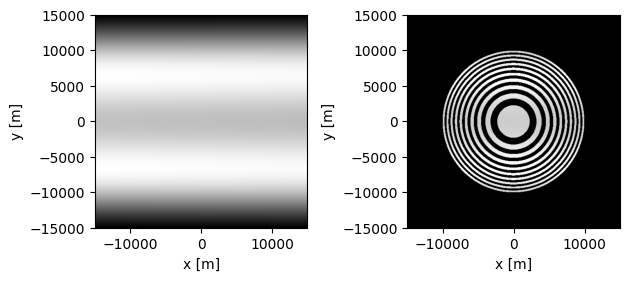

In [58]:
bm = srwave.BendingMagnet(B=1.4,L=3)
fields = srwave.MagnetCnt(magnets=[bm],fieldtype='bending')

w = np.linspace(-15,15,500)*1e-3

SR = srwave.SynchrotronRadiation(energy=3.8,d=5,x=w,y=w,fields=fields)
SR.calc_wfr()

ax1 = plt.subplot(121)
SR.plot_intensity(coords='xy',energy=Eph,X=0,Y=0,
                  ax=ax1, xlabel='x [m]', ylabel='y [m]')


zp = srwave.FresnelZonePlate(nr_zones=19,radius_n=0.01)
bl = srwave.Beamline(radiation=SR,opt_elements=[zp])
bl.propagate_wfr()


ax2 = plt.subplot(122)
SR.plot_intensity(coords='xy',energy=Eph,X=0,Y=0,
                  ax=ax2, xlabel='x [m]', ylabel='y [m]')

plt.tight_layout()
plt.show()

# Beamlines

simple propagation

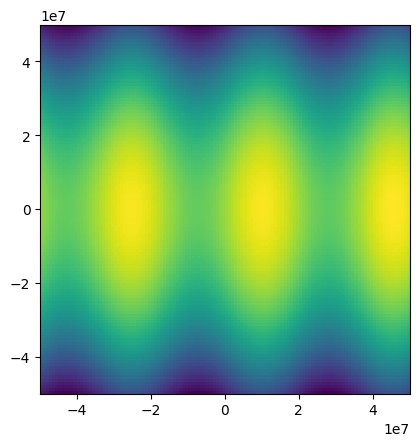

In [60]:
Eph = 22e3
apert = 25e-6
w = np.linspace(-50,50,120)*1e-6

bm = srwave.BendingMagnet(B=0.5642,L=3)
fields = srwave.MagnetCnt(magnets=[bm],fieldtype='bending')

SR = srwave.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()


arrI, [rangex,rangey] = SR.calc_intensity(coords='xy',energy=Eph,X=0,Y=0,polarization='total',calctype='SE')
xi, xf, nx, yi, yf, ny = *rangex, *rangey
arrI = np.array(arrI).reshape(ny,nx)

limits = SR.window_limits() * 1e6
plt.imshow(arrI,extent=limits)
plt.show()

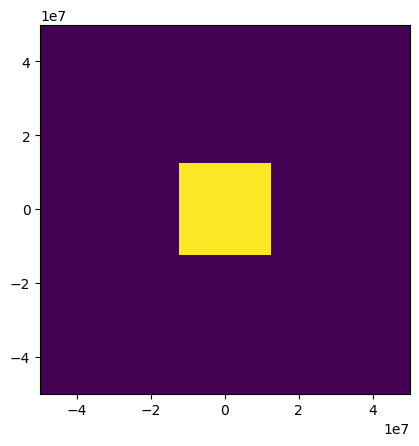

In [62]:
Eph = 22e3
apert = 25e-6
w = np.linspace(-50,50,120)*1e-6

bm = srwave.BendingMagnet(B=0.5642,L=3)
fields = srwave.MagnetCnt(magnets=[bm],fieldtype='bending')

SR = srwave.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()

aper = srwave.Slit(apert,apert)

bl = srwave.Beamline(radiation=SR,opt_elements=[aper])
bl.propagate_wfr()


arrI, [rangex,rangey] = SR.calc_intensity(coords='xy',energy=Eph,X=0,Y=0,polarization='total',calctype='SE')
xi, xf, nx, yi, yf, ny = *rangex, *rangey
arrI = np.array(arrI).reshape(ny,nx)

limits = SR.window_limits() * 1e6
plt.imshow(arrI,extent=limits)
plt.show()

## Pinhole

construction of the beamline

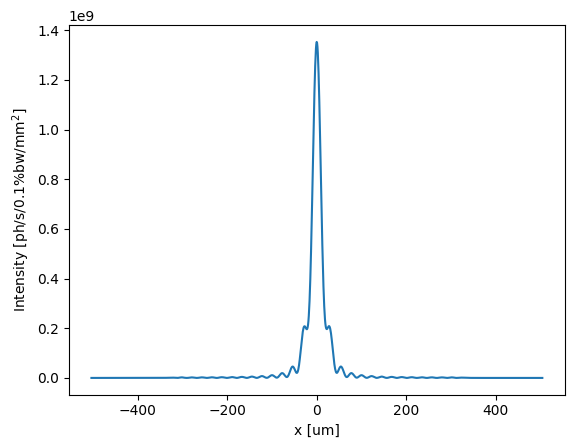

In [64]:
Eph = 22e3
apert = 25e-6
w = np.linspace(-50,50,120)*1e-6

bm = srwave.BendingMagnet(B=0.5642,L=3)
fields = srwave.MagnetCnt(magnets=[bm],fieldtype='bending')

SR = srwave.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
# SR.load_beam('carcara')
SR.calc_wfr()
SR.load_beam('carcara')

filtro = srwave.AbsorptionFilter(x=w,y=w,energy=Eph,thickness=1e-3,material='Al')
aper = srwave.Slit(apert,apert)
aper.prop_params['ra'] = 10.0
screen = srwave.Drift(distance=10)
bl = srwave.Beamline(radiation=SR,opt_elements=[filtro,aper,screen])
bl.propagate_wfr()

arrIx, [rangex] = SR.calc_intensity(coords='x',energy=Eph,X=0,Y=0,polarization='total',calctype='SE')
x = np.linspace(*rangex)*1e6

plt.plot(x,arrIx)
plt.xlabel('x [um]')
plt.ylabel(r'Intensity [ph/s/0.1%bw/mm$^2$]')
plt.show()

fluence

electric field

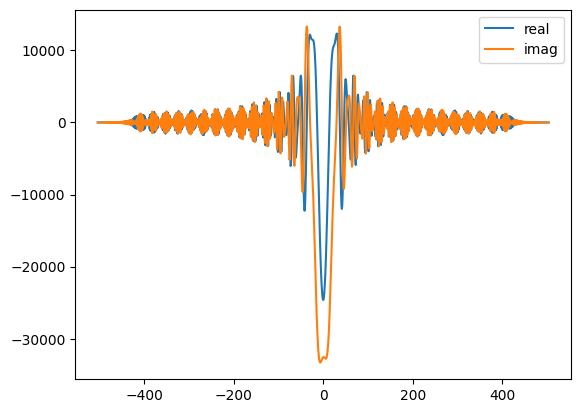

In [12]:
w = np.linspace(-50,50,120)*1e-6
bl = srwave.PinholeLine(energy=17.5e3,d=10,D=10,x=w,y=w,apertx=25e-6,aperty=25e-6)

[arrReE, arrImE], [rangex] = bl.radiation.calc_electric_field(part='re-im',coords='x',energy=0,X=0,Y=0,polarization='total')
x = np.linspace(*rangex)*1e6

plt.plot(x,arrReE,label='real')
plt.plot(x,arrImE,label='imag')
plt.legend()
plt.show()

gaussian fitting

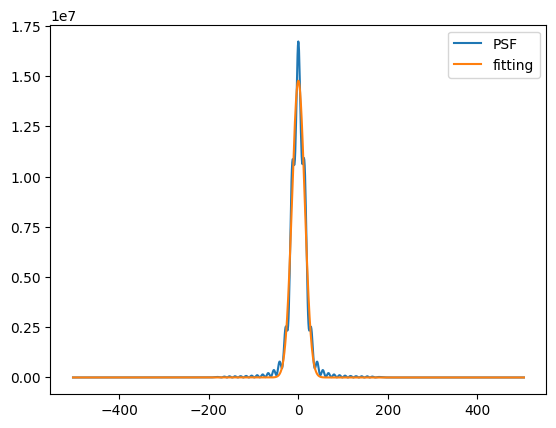

In [13]:
Eph = 40e3
w = np.linspace(-50,50,120)*1e-6
bl = srwave.PinholeLine(energy=Eph,d=10,D=10,x=w,y=w,apertx=25e-6,aperty=25e-6)

arrIx, [rangex] = bl.radiation.calc_intensity(coords='x',energy=Eph,X=0,Y=0,polarization='total',calctype='SE')
x = np.linspace(*rangex)*1e6

params = srwave.utils.fitgaussian(x,arrIx)

plt.plot(x,arrIx,label='PSF')
plt.plot(x,srwave.utils.gaussian(x,*params),label='fitting')
plt.legend()
plt.show()

FWHM of peak-type intensities

FWHM:
- x: 26.07
- y: 26.08


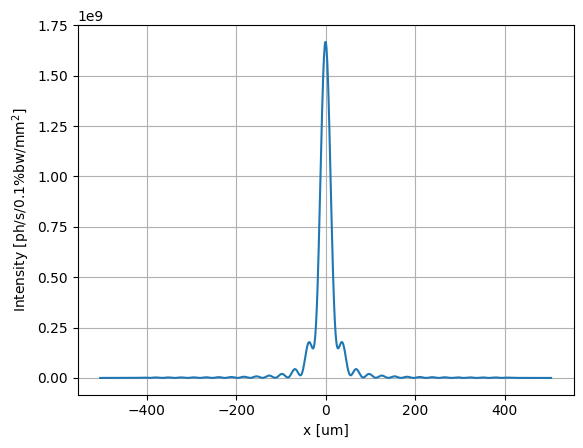

In [15]:
w = np.linspace(-50,50,120)*1e-6
bl = srwave.PinholeLine(energy=17.5e3,d=10,D=10,x=w,y=w,apertx=25e-6,aperty=25e-6)

print("FWHM:",
      f"- x: {srwave.utils.fwhm_SR(bl.radiation,coords='x',energy=Eph,X=0,Y=0):.2f}",
      f"- y: {srwave.utils.fwhm_SR(bl.radiation,coords='y',energy=Eph,X=0,Y=0):.2f}",
      sep='\n')
bl.radiation.plot_intensity(coords='x',energy=Eph,X=0,Y=0,
                    xlabel='x [um]',ylabel=r'Intensity [ph/s/0.1%bw/mm$^2$]')

caustic

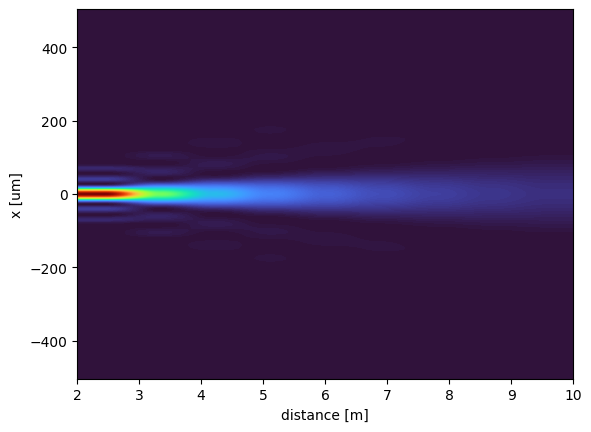

In [ ]:
Eph = 17.5e3
w = np.linspace(-50,50,120)*1e-6
apert = 5e-6

bm = srwave.BendingMagnet(B=0.5642,L=2)
fields = srwave.MagnetCnt(magnets=[bm],field_type='bending')

SR = srwave.SynchrotronRadiation(energy=Eph,d=10,x=w,y=w,fields=fields)
SR.calc_wfr()

filtro = srwave.AbsorptionFilter(x=w,y=w,energy=Eph,thickness=1e-3,material='Al')
aper = srwave.Slit(apert,apert)
aper.prop_params['ra'] = 10.0
# screen = Slit(dist=d)
# bl = Beamline(line=[filtro,aper,screen])
bl = srwave.Beamline(radiation=SR, line=[filtro,aper])
bl.propagate_wfr()


distances = np.linspace(2,10,9)

arrsI, ranges = srwave.beamlines.caustic(SR,dists=distances,coord='x',energy=Eph,X=0,Y=0)

limits = [distances[0],distances[-1],ranges[0][0]*1e6,ranges[0][1]*1e6]
plt.imshow(arrsI,extent=limits,aspect='auto',cmap='turbo')
plt.ylabel('x [um]')
plt.xlabel('distance [m]')
plt.show()

## Toroidal Mirror

FWHM:
- x: 0.43
- y: 0.71


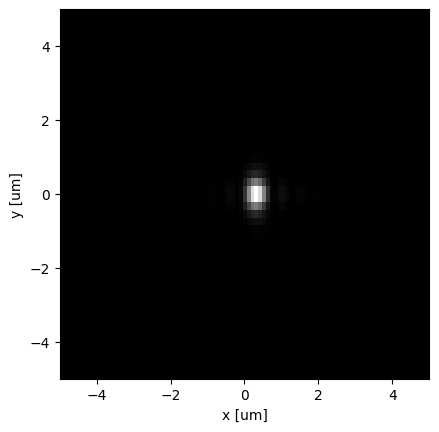

In [3]:
w = np.linspace(-3,3,200)*1e-3
SR = bln.ToroidalMirrorLine(energy=11e3,d=17,D=17,x=w,y=w,apertx=4e-3,aperty=4e-3,
                            ang=18.78e-3,tang_len=0.22,sag_len=0.008,R_tang=905.271,
                            R_sag=0.3192)

print("FWHM:",
      f"- x: {uti.fwhm_SR(SR,coords='x',energy=11e3,X=0,Y=0):.2f}",
      f"- y: {uti.fwhm_SR(SR,coords='y',energy=11e3,X=0,Y=0):.2f}",
      sep='\n')
rplt.plot_wfr_inten(SR,coords='xy',energy=11e3,X=0,Y=0,aspect='equal',
                    xlim=(-5,5),ylim=(-5,5),xlabel='x [um]',ylabel='y [um]')

## CARCARA

FWHM:
- x: 0.44
- y: 0.86


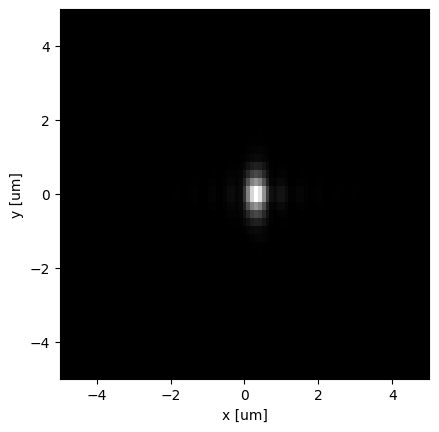

In [2]:
SR = bln.Carcara(apertx=5e-3,aperty=5e-3)

print("FWHM:",
      f"- x: {uti.fwhm_SR(SR,coord='x',energy=11e3,X=0,Y=0):.2f}",
      f"- y: {uti.fwhm_SR(SR,coord='y',energy=11e3,X=0,Y=0):.2f}",
      sep='\n')
rplt.plot_wfr_inten(SR,coords='xy',energy=11e3,X=0,Y=0,aspect='equal',
               xlim=(-5,5),ylim=(-5,5),xlabel='x [um]',ylabel='y [um]')

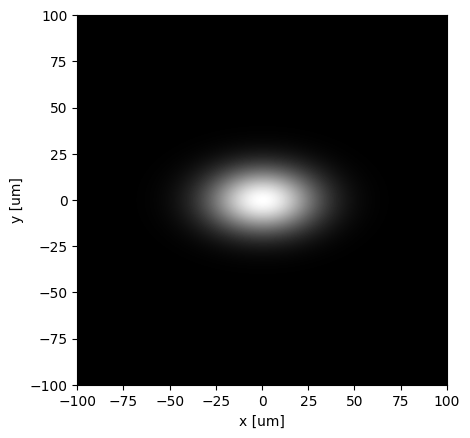

In [3]:
SR = bln.Carcara(apertx=5e-3,aperty=5e-3)

rplt.plot_wfr_inten(SR,coords='xy',energy=11e3,X=0,Y=0,aspect='equal',intType='ME',
                    xlabel='x [um]',ylabel='y [um]',xlim=(-100,100),ylim=(-100,100))

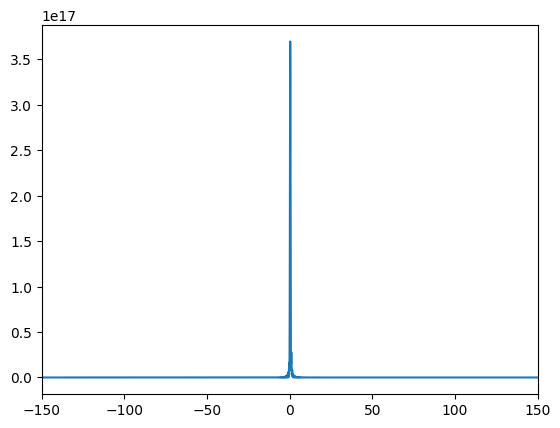

In [4]:
SR = bln.Carcara(apertx=5e-3,aperty=5e-3,mirror_error='')

rplt.plot_wfr_inten(SR,coords='x',energy=11e3,X=0,Y=0,xlim=(-150,150))

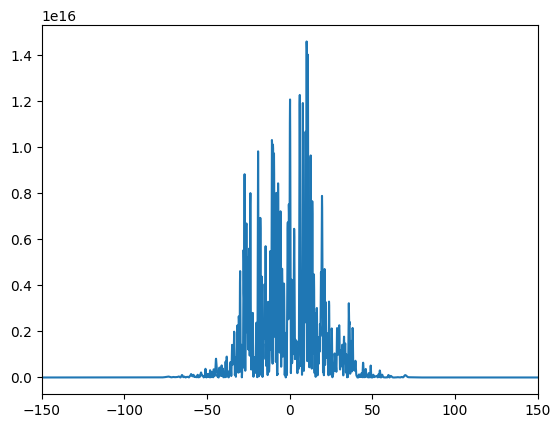

In [5]:
SR = bln.Carcara(apertx=5e-3,aperty=5e-3,mirror_error='meas')

rplt.plot_wfr_inten(SR,coords='x',energy=11e3,X=0,Y=0,xlim=(-150,150))

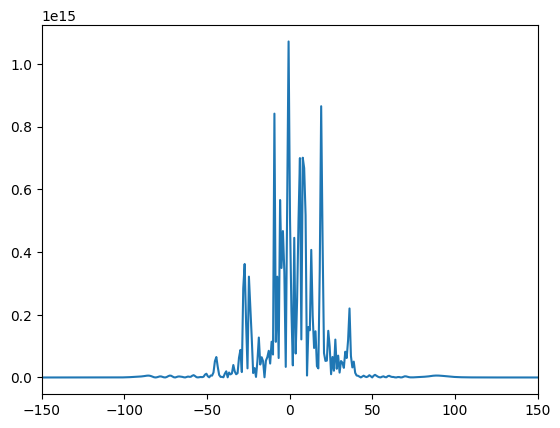

In [6]:
SR = bln.Carcara(apertx=1e-3,aperty=1e-3,mirror_error='meas')

rplt.plot_wfr_inten(SR,coords='x',energy=11e3,X=0,Y=0,xlim=(-150,150))